In [ ]:
import pandas as pd
from sqlalchemy import create_engine
from matplotlib.gridspec import GridSpec as gs
import matplotlib.pyplot as plt

engine = create_engine(
    "postgresql+psycopg2://postgres@localhost:5432/portfolio (telecom)"
)

df = pd.read_sql(
    "SELECT current_database();",
    engine
)
print(df)


      current_database
0  portfolio (telecom)


In [ ]:
df = pd.read_sql(
    """select
    churn,
    count(*) customers,
    round(count(*) * 100.0 / sum(count(*)) over(), 2) percent_customers
from telecom
group by churn""",
    engine
)

display(df)


,churn,customers,percent_customers
0,No,5174,73.46
1,Yes,1869,26.54


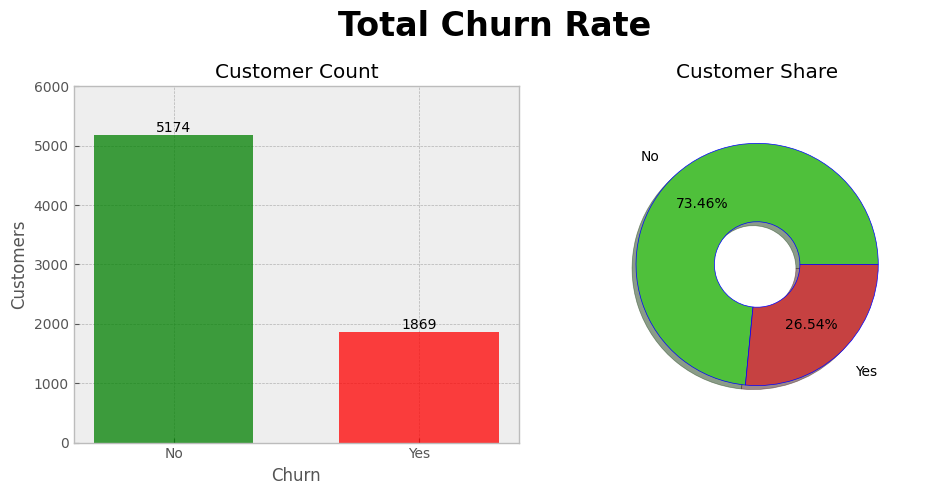

In [178]:
fig, ax = plt.subplots(1, 2, figsize = (10,5))
plt.style.use('bmh')

fig.suptitle(
    'Total Churn Rate',
    fontsize=24,
    fontweight='bold')

ax[1].pie(
    df['percent_customers'], 
    labels = df['churn'],
    shadow = True,
    colors = ["#4FC03B", "#C64141"],
    radius = 0.85,
    autopct='%1.2f%%',
    pctdistance=0.67,
    labeldistance = 1.2,
    wedgeprops={
        'edgecolor': 'b',
        'width' : 0.55,
        })


bars = ax[0].bar(df['churn'], 
          df['customers'],
          color=['green', 'red'],
          alpha = 0.75,
          width = 0.65
          )
ax[0].set_ylim(0, 6000)
ax[0].set_xlabel('Churn')
ax[0].set_ylabel('Customers')
ax[0].bar_label(bars)
ax[0].set_title('Customer Count')
ax[1].set_title('Customer Share')
plt.tight_layout()


In [313]:
df = pd.read_sql(
    """-- Анализ влияния параметров на churn:
with all_churn_rate as(
	select
		'tenure' parametr,
		case
			when tenure <= 6 then '0-6 months'
			when tenure <= 24 then '7-24 months'
			when tenure <= 48 then '25-48 months'
			else '48+ months'
		end as segment,
		round(avg(case when churn = 'Yes' then 1 else 0 end), 2) churn_rate
	from telecom
	group by segment

	union all

/* Значения, которые подставим в case под monthly_charges
 select
    min(monthly_charges),
    percentile_cont(0.25) within group (order by monthly_charges),
    percentile_cont(0.5) within group (order by monthly_charges),
    percentile_cont(0.75) within group (order by monthly_charges),
    max(monthly_charges)
from telecom */

	select
		'monthly_charges' parametr,
		case
			when monthly_charges < 35.5 then '< 35.5 (low)'
			when monthly_charges < 70.35 then '< 70.35 (medium)'
			else '> 70.35 (high)'
		end segment,
		round(avg(case when churn = 'Yes' then 1 else 0 end), 2) churn_rate
		from telecom
		group by segment

	union all

	select
		'internet_service' parametr,
		internet_service as segment,
		round(avg(case when churn = 'Yes' then 1 else 0 end), 2) churn_rate
	from telecom
	group by segment

	union all

	select
		'online_backup' parametr,
		online_backup as segment,
		round(avg(case when churn = 'Yes' then 1 else 0 end), 2) churn_rate
	from telecom
	group by segment

	union all

	select
		'tech_support' parametr,
		tech_support as segment,
		round(avg(case when churn = 'Yes' then 1 else 0 end), 2) churn_rate
	from telecom
	group by segment

	union all

	select
		'streaming_tv' parametr,
		streaming_tv as segment,
		round(avg(case when churn = 'Yes' then 1 else 0 end), 2) churn_rate
	from telecom
	group by segment

	union all

	select
		'contract' parametr,
		contract as segment,
		round(avg(case when churn = 'Yes' then 1 else 0 end), 2) churn_rate
	from telecom
	group by segment
), general_churn_rate as(
	select
		round(avg(case when churn = 'Yes' then 1 else 0 end), 2) general_churn_rate
	from telecom
)
select
	acr.*,
	gcr.general_churn_rate,
	round(acr.churn_rate - gcr.general_churn_rate, 2) as churn_diff
from all_churn_rate acr
cross join general_churn_rate gcr
order by churn_rate desc""",
    engine)


df_raw = pd.read_sql(
    """select
    *
   from telecom""",
    engine)

display(df)

import seaborn as sns

retained_clients = df.sort_values(
    'churn_diff'
).head(5)

churned_clients = df.sort_values(
    'churn_diff',
    ascending=False
).head(5)

display(churned_clients)
display(retained_clients)



,parametr,segment,churn_rate,general_churn_rate,churn_diff
0,tenure,0-6 months,0.53,0.27,0.26
1,contract,Month-to-month,0.43,0.27,0.16
2,tech_support,No,0.42,0.27,0.15
3,internet_service,Fiber optic,0.42,0.27,0.15
4,online_backup,No,0.40,0.27,0.13
5,monthly_charges,> 70.35 (high),0.35,0.27,0.08
6,streaming_tv,No,0.34,0.27,0.07
7,tenure,7-24 months,0.32,0.27,0.05
8,streaming_tv,Yes,0.30,0.27,0.03
9,monthly_charges,< 70.35 (medium),0.25,0.27,-0.02


,parametr,segment,churn_rate,general_churn_rate,churn_diff
0,tenure,0-6 months,0.53,0.27,0.26
1,contract,Month-to-month,0.43,0.27,0.16
2,tech_support,No,0.42,0.27,0.15
3,internet_service,Fiber optic,0.42,0.27,0.15
4,online_backup,No,0.40,0.27,0.13


,parametr,segment,churn_rate,general_churn_rate,churn_diff
21,contract,Two year,0.03,0.27,-0.24
19,tech_support,No internet service,0.07,0.27,-0.20
18,internet_service,No,0.07,0.27,-0.20
17,online_backup,No internet service,0.07,0.27,-0.20
20,streaming_tv,No internet service,0.07,0.27,-0.20


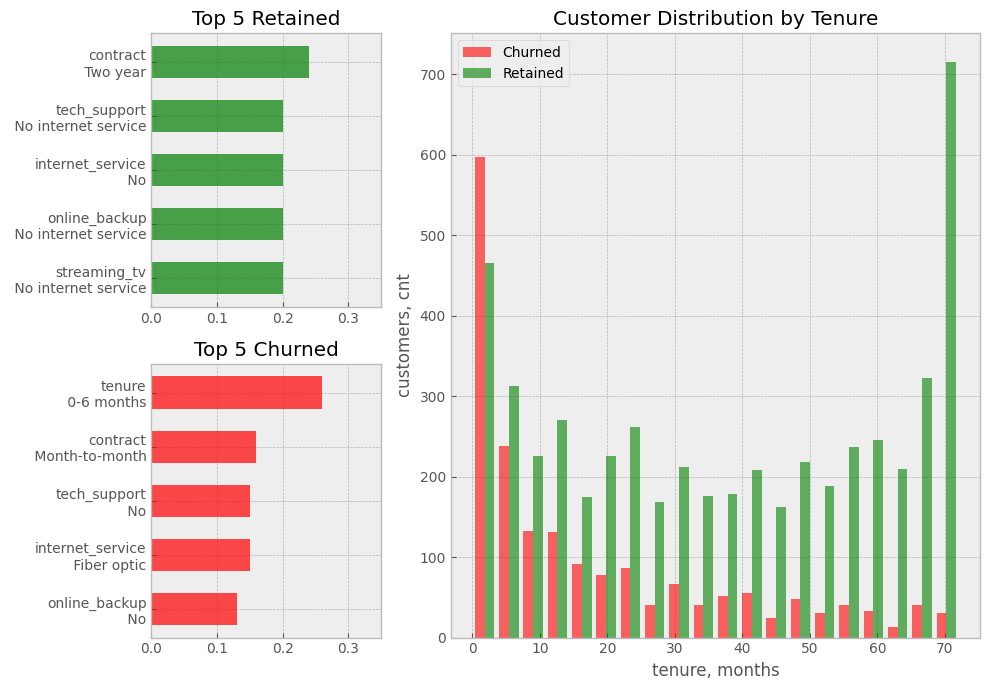

In [314]:
plt.style.use('bmh')
fig = plt.figure(figsize = (10,7))

gs = GridSpec(nrows=2, ncols=3, figure=fig)


retained_clients['label'] = (
    retained_clients['parametr'] + '\n ' + retained_clients['segment'])

churned_clients['label'] = (
    churned_clients['parametr'] +  '\n ' + churned_clients['segment'])

ax1 = fig.add_subplot(gs[0,0])
ax1.barh(retained_clients['label'], 
         retained_clients['churn_diff'].abs(),
        height = 0.6,
        color = 'green',
        alpha = 0.7)
ax1.set_title('Top 5 Retained')
ax1.set_xlim(0, 0.35)
ax1.invert_yaxis()

ax2 = fig.add_subplot(gs[1,0])
ax2.set_title('Top 5 Churned')
ax2.barh(churned_clients['label'], 
         churned_clients['churn_diff'].abs(),
         height = 0.6,
        color = 'red',
        alpha = 0.7)
ax2.set_xlim(0, 0.35)
ax2.invert_yaxis()

ax3 = fig.add_subplot(gs[0:,1:])
ax3.hist(
    [df_raw[df_raw['churn']=='Yes']['tenure'],
     df_raw[df_raw['churn']=='No']['tenure']],
    bins=20,
    color=['red', 'green'],
    label=['Churned', 'Retained'],
    alpha = 0.6)
ax3.legend()
ax3.set_xlabel('tenure, months')
ax3.set_ylabel('customers, cnt') 
ax3.set_title('Customer Distribution by Tenure')

plt.tight_layout()